                                 User
    +-------------------------------------------------------------+
    |                            CCXT                             |
    +------------------------------+------------------------------+
    |            Public            |           Private            |
    +=============================================================+
    │                              .                              |
    │                    The Unified CCXT API                     |
    │                              .                              |
    |       loadMarkets            .           fetchBalance       |
    |       fetchMarkets           .            createOrder       |
    |       fetchCurrencies        .            cancelOrder       |
    |       fetchTicker            .             fetchOrder       |
    |       fetchTickers           .            fetchOrders       |
    |       fetchOrderBook         .        fetchOpenOrders       |
    |       fetchOHLCV             .      fetchClosedOrders       |
    |       fetchStatus            .          fetchMyTrades       |
    |       fetchTrades            .                deposit       |
    |                              .               withdraw       |
    │                              .                              |
    +=============================================================+
    │                              .                              |
    |                     Custom Exchange API                     |
    |         (Derived Classes And Their Implicit Methods)        |
    │                              .                              |
    |       publicGet...           .          privateGet...       |
    |       publicPost...          .         privatePost...       |
    |                              .          privatePut...       |
    |                              .       privateDelete...       |
    |                              .                   sign       |
    │                              .                              |
    +=============================================================+
    │                              .                              |
    |                      Base Exchange Class                    |
    │                              .                              |
    +=============================================================+


## Instantiation

In [3]:
import ccxt
print(ccxt.exchanges)

['alp', 'alpaca', 'apex', 'arkham', 'ascendex', 'aster', 'backpack', 'bequant', 'bigone', 'binance', 'binancecoinm', 'binanceus', 'binanceusdm', 'bingx', 'bit2c', 'bitbank', 'bitbns', 'bitfinex', 'bitflyer', 'bitget', 'bithumb', 'bitmart', 'bitmex', 'bitopro', 'bitrue', 'bitso', 'bitstamp', 'bitteam', 'bittrade', 'bitvavo', 'blockchaincom', 'blofin', 'btcbox', 'btcmarkets', 'btcturk', 'bullish', 'bybit', 'bydfi', 'cex', 'coinbase', 'coinbaseadvanced', 'coinbaseexchange', 'coinbaseinternational', 'coincatch', 'coincheck', 'coinex', 'coinmate', 'coinmetro', 'coinone', 'coinsph', 'coinspot', 'cryptocom', 'cryptomus', 'deepcoin', 'defx', 'delta', 'deribit', 'derive', 'digifinex', 'dydx', 'exmo', 'fmfwio', 'foxbit', 'gate', 'gateio', 'gemini', 'hashkey', 'hibachi', 'hitbtc', 'hollaex', 'htx', 'huobi', 'hyperliquid', 'independentreserve', 'indodax', 'kraken', 'krakenfutures', 'kucoin', 'kucoinfutures', 'latoken', 'lbank', 'luno', 'mercado', 'mexc', 'modetrade', 'myokx', 'ndax', 'novadax', 'o

### Instantiation Example

### Markets

In [4]:
# exchange instantiation
exchange = ccxt.binance({'enableRateLimit': True})
exchange.enableRateLimit = True
exchange_id = exchange.id # binance in this case

# Load markets first
exchange.load_markets()

# Currencies dict
currencies = exchange.currencies

btc_market = exchange.markets['BTC/USDT'] # get market structure by symbol

btcid = exchange.market_id('BTC/USDT') # get market id by symbol
btcid2 = exchange.markets['BTC/USDT']['id'] # get market id by symbol

market_by_id = exchange.markets_by_id['BTCUSDT'][0] # get market by id
id_by_symbol = exchange.markets_by_id['BTCUSDT'][0]['symbol'] # get symbol by id

symbols = exchange.symbols # get a list of symbols
symbols2 = list(exchange.markets.keys())

### Price Tickers

In [5]:
# Tickers are a snapshot of the current state of the market

btc_ticker = exchange.fetchTicker('BTC/USDT') # single ticker
btc_eth_t = exchange.fetchTickers(['BTC/USDT', 'ETH/USDT']) # multi ticker, defaults to all

### OHLCV

In [104]:
import time
import datetime as dt # important for since
import pandas as pd

now = dt.datetime.utcnow()
start = now - dt.timedelta(hours = 24*365)
start = start.replace(second=0, microsecond=0, minute=0)
since = int(start.replace(tzinfo=dt.timezone.utc).timestamp() * 1000)
until = now - dt.timedelta(hours = 1)
until = int(until.timestamp() * 1000)


# debug time
print(dt.datetime.utcfromtimestamp(since / 1000))
print(dt.datetime.utcfromtimestamp(until / 1000))

if exchange.has['fetchOHLCV']:
    btc_ohlcv = exchange.fetchOHLCV(symbol = 'BTC/USDT', timeframe = '1h', since=since,limit=1000, params={'until':until})
    time.sleep(exchange.rateLimit / 1000) # very important to not hit rate limit

2025-01-30 21:00:00
2026-01-30 20:25:13.265000


### more OHLCV ... with pandas

In [105]:
df = pd.DataFrame(btc_ohlcv)
columns = ['Timestamp', 'Open', 'High', 'Low', 'Close', 'Volume']
df.columns = columns
df['Datetime'] = pd.to_datetime(df['Timestamp'], unit='ms', utc=True)
df.to_csv('datasets/jan221dto8pmBTC.csv')

In [106]:
import numpy as np

In [107]:
def prepare_features(df):
    df['Return'] = df['Close'].pct_change()*100
    df['log_return'] = np.log(df['Close']).diff()
    return df.dropna()

In [108]:
df = prepare_features(df)

In [109]:
log_return_dict = df['log_return'].describe().to_dict()
log_return_dict

{'count': 999.0,
 'mean': -0.0002416511818451371,
 'std': 0.00681250855645619,
 'min': -0.050194534107680155,
 '25%': -0.002600601853409934,
 '50%': 6.78998178926804e-06,
 '75%': 0.00252014593635419,
 'max': 0.042239413972183115}

<Axes: >

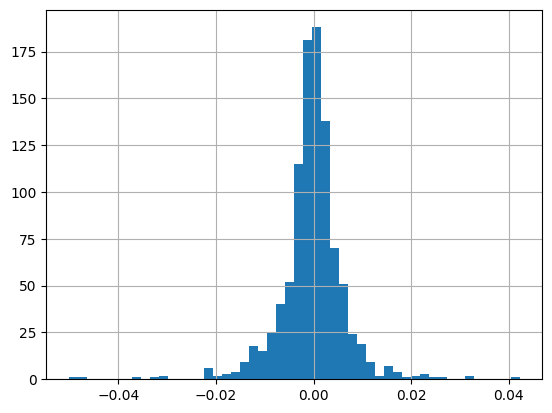

In [110]:
log_return = df['log_return']
log_return.hist(bins=50)

In [113]:
log_return_dict['skew'] = float(df['log_return'].skew())
log_return_dict['kurtosis'] = float(df['log_return'].kurt())

log_return_dict

{'count': 999.0,
 'mean': -0.0002416511818451371,
 'std': 0.00681250855645619,
 'min': -0.050194534107680155,
 '25%': -0.002600601853409934,
 '50%': 6.78998178926804e-06,
 '75%': 0.00252014593635419,
 'max': 0.042239413972183115,
 'skew': -0.6686364956936252,
 'kurtosis': 9.926795226612978}

<Axes: >

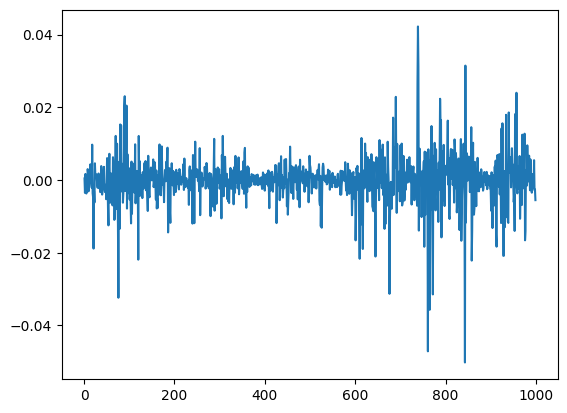

In [116]:
log_return.plot()

## Constructing top-m Liquid Crypto Assets ##

In [2]:
import ccxt
import time
import datetime as dt # important for since
import pandas as pd

m = 50
N = 100

exchange = 

In [ ]:
# then we want m x N matrix of log returns for m crypto assets across N days.
# we will use quoteVolume with quote currency = USDT

m_assets = []

